# Biblioteca

In [2]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [21]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.preprocessing import LabelEncoder

# Carregado Arquivos e Primeiras Análises

Dataset carregado com sucesso!


,Pais,Regiao,Ano,Segmento,powertrain_type,Vendas_EV,Vendas_Gasolina,Vendas_Diesel,total_vehicle_sales,Market_Share_EV,...,avg_ev_range_km,Preco_Gasolina_USD,electricity_price_usd_per_kwh,PIB_per_Capita,urban_population_percent,co2_emissions_transport_mt,ev_subsidy_usd,emission_regulation_score,ev_growth_rate_yoy,is_ev_dominant
0,Australia,Oceania,2010,commercial,ICE,5,92877,61921,154803,0.00,...,124,1.09,0.149,51977,88.8,88.7,0,30.4,0.00,0
1,Australia,Oceania,2010,mass_market,ICE,57,535933,73089,609079,0.01,...,124,1.09,0.149,51977,88.8,88.7,0,30.4,0.00,0
2,Australia,Oceania,2010,premium,ICE,37,235282,20462,255781,0.01,...,124,1.09,0.149,51977,88.8,88.7,0,30.4,0.00,0
3,Australia,Oceania,2011,commercial,ICE,11,98092,65395,163498,0.01,...,133,1.09,0.163,52807,88.9,88.3,0,30.8,120.00,0
4,Australia,Oceania,2011,mass_market,ICE,129,569679,77684,647492,0.02,...,133,1.09,0.163,52807,88.9,88.3,0,30.8,126.32,0


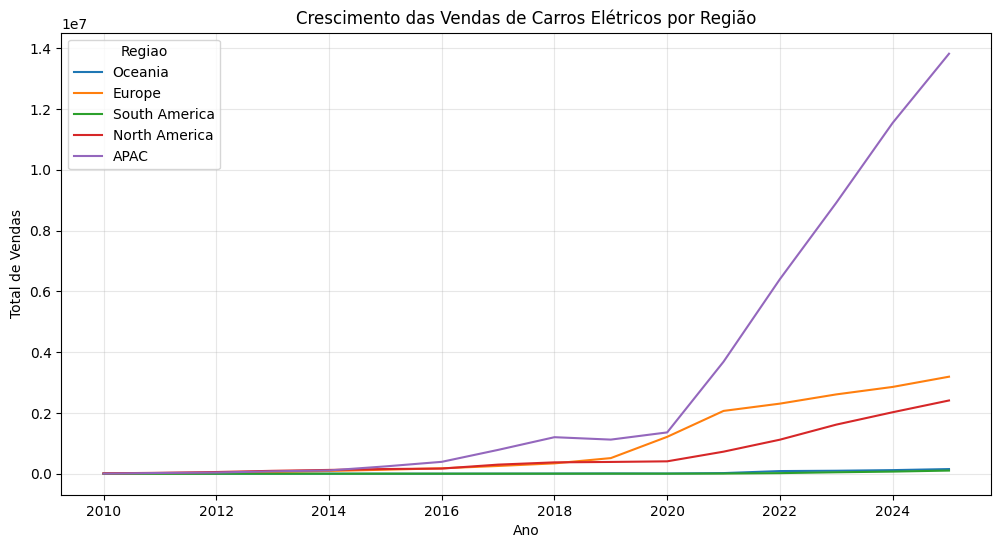

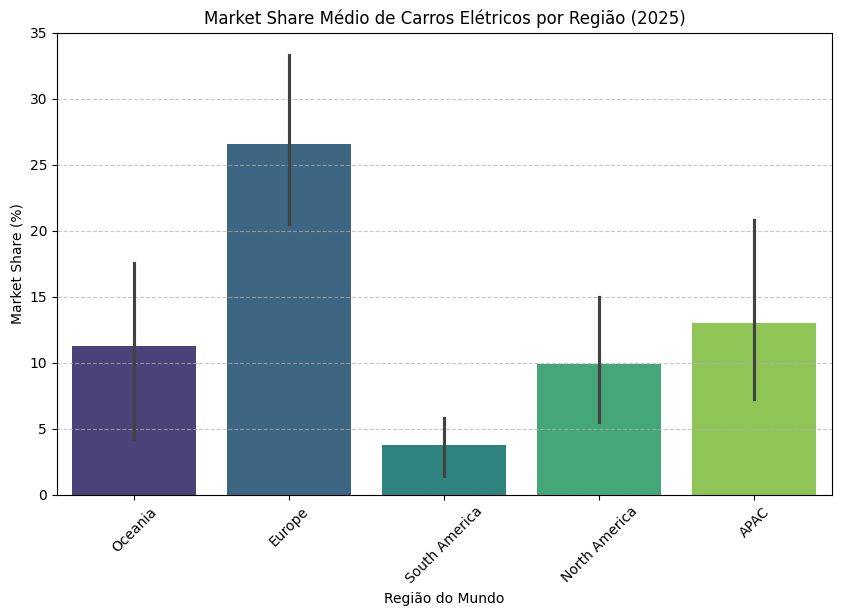

In [11]:
# 1. Carregar   dataset
df = pd.read_csv('ev_vs_petrol_dataset_v3.csv')

# 2. Traduzir as colunas para facilitar a análise
df_traduzido = df.rename(columns={
    'country': 'Pais',
    'region': 'Regiao',
    'year': 'Ano',
    'vehicle_segment': 'Segmento',
    'ev_sales': 'Vendas_EV',
    'petrol_car_sales': 'Vendas_Gasolina',
    'diesel_car_sales': 'Vendas_Diesel',
    'ev_market_share': 'Market_Share_EV',
    'charging_stations': 'Postos_Recarga',
    'fuel_price_usd_per_liter': 'Preco_Gasolina_USD',
    'gdp_per_capita': 'PIB_per_Capita'
})

print("Dataset carregado com sucesso!")
display(df_traduzido.head())

# --- VISUALIZAÇÃO 1: Tendência Global de Vendas ---
plt.figure(figsize=(12, 6))
sns.lineplot(data=df_traduzido, x='Ano', y='Vendas_EV', hue='Regiao', estimator='sum', errorbar=None)
plt.title('Crescimento das Vendas de Carros Elétricos por Região')
plt.ylabel('Total de Vendas')
plt.grid(True, alpha=0.3)
plt.show()

# --- VISUALIZAÇÃO 2: Preço da Gasolina vs Market Share de EV ---
plt.figure(figsize=(10, 6))

ano_max = df_traduzido['Ano'].max()
df_recente = df_traduzido[df_traduzido['Ano'] == ano_max]

sns.barplot(data=df_recente, x='Regiao', y='Market_Share_EV', palette='viridis', hue='Regiao', legend=False)
plt.title(f'Market Share Médio de Carros Elétricos por Região ({ano_max})')
plt.xlabel('Região do Mundo')
plt.ylabel('Market Share (%)')
plt.xticks(rotation=45) # Inclina os nomes das regiões para não sobrepor
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## 1. Evolução ao longo do tempo (Gráfico de Linhas)

Os dados mostram que, durante muitos anos, as vendas de carros elétricos quase não alteraram. Recentemente, houve um crescimento rápido e constante. Isso indica que a transição para estes veículos está a acelerar em nível global.

## 2. Comparação entre regiões (Gráfico de Barras)

A substituição de carros a gasolina não acontece da mesma forma em todos os lugares. Algumas regiões apresentam uma adesão muito alta, enquanto outras ainda possuem poucos veículos elétricos em circulação. Isso demonstra uma grande diferença no ritmo de mudança entre os países.

## 3. Importância da infraestrutura

O aumento das vendas está diretamente ligado à quantidade de postos de recarga disponíveis. Países que instalam mais carregadores públicos registam um crescimento maior nas vendas, pois os condutores sentem mais segurança ao utilizar o veículo.

## 4. Influência do preço do combustível

O valor da gasolina também afeta os números. Em locais onde o combustível comum é mais caro, a procura por carros elétricos é maior. O custo de utilização torna-se um fator decisivo para os consumidores abandonarem os carros tradicionais.

## 5. Concentração de mercado

Atualmente, a maior parte das vendas mundiais está concentrada em poucos países líderes. Isto significa que, embora o crescimento seja rápido, a mudança ainda não atingiu a maioria das nações de forma equilibrada.

# Engenharia de Atributos

In [12]:
# 1. Criar a proporção de postos de recarga por total de veículos
df_traduzido['Postos_por_Veiculo'] = df_traduzido['Postos_Recarga'] / df_traduzido['total_vehicle_sales']

# 2. Calcular a diferença de preço entre gasolina e eletricidade
df_traduzido['Diferenca_Custo_Energia'] = df_traduzido['Preco_Gasolina_USD'] - df_traduzido['electricity_price_usd_per_kwh']

# 3. Agrupar o PIB em 3 níveis: Baixo, Médio e Alto
df_traduzido['Nivel_Economico'] = pd.qcut(df_traduzido['PIB_per_Capita'], q=3, labels=['Baixo', 'Medio', 'Alto'])

print("Novas informações criadas com sucesso.")
display(df_traduzido[['Pais', 'Postos_por_Veiculo', 'Diferenca_Custo_Energia', 'Nivel_Economico']].head())

Novas informações criadas com sucesso.


,Pais,Postos_por_Veiculo,Diferenca_Custo_Energia,Nivel_Economico
0,Australia,0.000000,0.941,Alto
1,Australia,0.000000,0.941,Alto
2,Australia,0.000000,0.941,Alto
3,Australia,0.000642,0.927,Alto
4,Australia,0.000162,0.927,Alto


# Treinando o Modelo

In [15]:
# 1. Transformar colunas de texto em números
le = LabelEncoder()
df_traduzido['Regiao_Cod'] = le.fit_transform(df_traduzido['Regiao'])
df_traduzido['Nivel_Economico_Cod'] = le.fit_transform(df_traduzido['Nivel_Economico'].astype(str))

# 2. Selecionar as informações para a previsão
caracteristicas = ['Ano', 'Regiao_Cod', 'Nivel_Economico_Cod', 'Postos_por_Veiculo', 'Diferenca_Custo_Energia']
X = df_traduzido[caracteristicas]
y = df_traduzido['Market_Share_EV']

# 3. Separar dados para treino (80%) e teste (20%)
X_treino, X_teste, y_treino, y_teste = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Treinar o modelo
modelo = RandomForestRegressor(n_estimators=100, random_state=42)
modelo.fit(X_treino, y_treino)

# 5. Calcular o erro médio
previsoes = modelo.predict(X_teste)
erro = mean_absolute_error(y_teste, previsoes)

print(f"Treinamento concluído. O erro médio do modelo é de {erro:.2f}%")

Treinamento concluído. O erro médio do modelo é de 4.15%


# Analise de Curva de Aprendizagem do Modelo

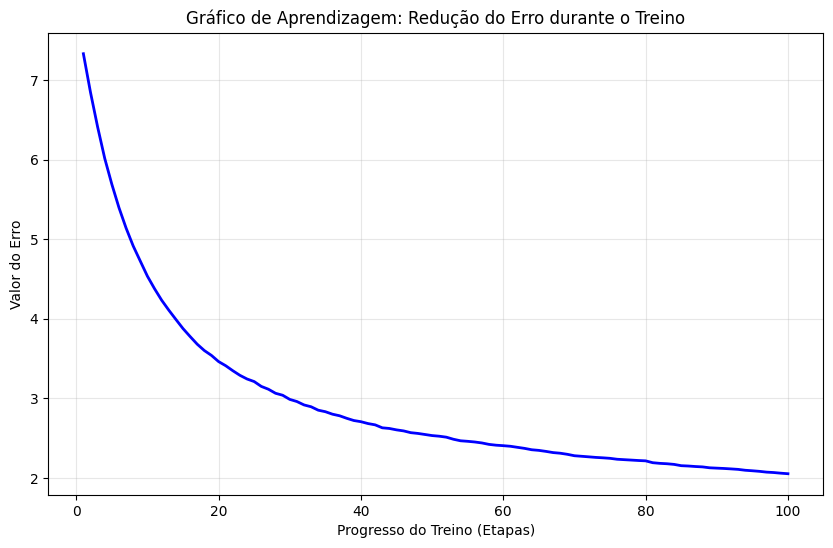

O gráfico mostra o erro a cair conforme o computador estuda os dados.


In [17]:
# 1. Usar um modelo que permite ver o erro passo a passo
modelo_progresso = GradientBoostingRegressor(n_estimators=100, random_state=42)
modelo_progresso.fit(X_treino, y_treino)

# 2. Calcular o erro em cada etapa do treino
erros_treino = []
for previsao_etapa in modelo_progresso.staged_predict(X_treino):
    erros_treino.append(mean_absolute_error(y_treino, previsao_etapa))

# 3. Gerar o gráfico
plt.figure(figsize=(10, 6))
plt.plot(range(1, 101), erros_treino, color='blue', linewidth=2)
plt.title('Gráfico de Aprendizagem: Redução do Erro durante o Treino')
plt.xlabel('Progresso do Treino (Etapas)')
plt.ylabel('Valor do Erro')
plt.grid(True, alpha=0.3)
plt.show()

print("O gráfico mostra o erro a cair conforme o computador estuda os dados.")

### 1. O que o gráfico mostra

A linha do gráfico começa numa posição alta, o que representa o erro inicial do computador quando ele ainda tem pouca informação. À medida que o processo avança, a linha desce. Se a linha terminar num nível baixo e estável, significa que o treino foi adequado e o modelo aprendeu os padrões corretamente sem apenas "decorar" os dados.

### 2. Verificação de estabilidade

Se a linha descesse e depois voltasse a subir, isso indicaria um erro no aprendizado. Como o erro final foi de $4.15\%$, o gráfico apresenta uma curva que desce de forma suave e termina constante. Este comportamento confirma que o computador aprendeu os padrões corretamente e que o modelo está estável.

# Simulador de Market Share para 2030

In [22]:
# 1. Criação do tradutor para as Regiões
le_regiao = LabelEncoder()
le_regiao.fit(df_traduzido['Regiao'])

# 2. Criação do tradutor para o Nível Econômico
le_nivel = LabelEncoder()
le_nivel.fit(df_traduzido['Nivel_Economico'].astype(str))

print("Ferramentas de tradução configuradas com sucesso.")
print(f"Regiões identificadas: {list(le_regiao.classes_)}")

Ferramentas de tradução configuradas com sucesso.
Regiões identificadas: ['APAC', 'Europe', 'North America', 'Oceania', 'South America']


c:\Users\Maiquel\Documents\Estudos\Machine-Learning\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
c:\Users\Maiquel\Documents\Estudos\Machine-Learning\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
c:\Users\Maiquel\Documents\Estudos\Machine-Learning\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
c:\Users\Maiquel\Documents\Estudos\Machine-Learning\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
c:\Users\Maiquel\Documents\Estudos\Machine-Learning\.venv\Lib\site-p

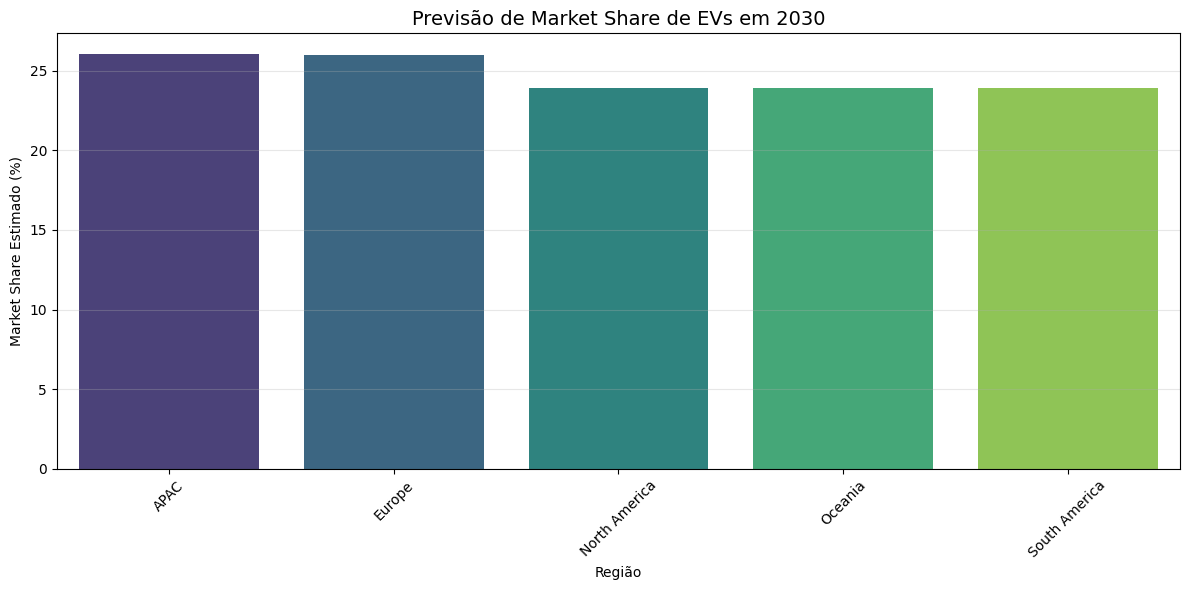

--- Valores Detalhados das Previsões para 2030 ---
Região: APAC                 | Market Share: 26.05%
Região: Europe               | Market Share: 26.01%
Região: North America        | Market Share: 23.93%
Região: Oceania              | Market Share: 23.93%
Região: South America        | Market Share: 23.93%


In [28]:
# 1. Definir o ano e calcular as previsões
ano_alvo = 2030
resultados_lista = []

for regiao in regioes:
    # Cenário padronizado para comparação
    valor_previsto = realizar_previsao(ano_alvo, regiao, 'Alto', 0.10, 1.70)
    resultados_lista.append({
        'Regiao': regiao,
        'Market_Share': valor_previsto
    })

# 2. Criar a tabela e ordenar do maior para o menor
df_final = pd.DataFrame(resultados_lista).sort_values(by='Market_Share', ascending=False)

# 3. Gerar o gráfico de barras
plt.figure(figsize=(12, 6))
sns.barplot(data=df_final, x='Regiao', y='Market_Share', palette='viridis', hue='Regiao', legend=False)

plt.title(f'Previsão de Market Share de EVs em {ano_alvo}', fontsize=14)
plt.ylabel('Market Share Estimado (%)')
plt.xlabel('Região')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# 4. Imprimir os valores exatos abaixo do gráfico
print(f"--- Valores Detalhados das Previsões para {ano_alvo} ---")
for index, linha in df_final.iterrows():
    print(f"Região: {linha['Regiao']:<20} | Market Share: {linha['Market_Share']:.2f}%")

**Média Geral Global**

In [29]:
# 1. Calcular a média dos valores da coluna Market_Share
media_global = df_final['Market_Share'].mean()

# 2. Exibir o resultado final
print(f"--- Resumo Global para {ano_alvo} ---")
print(f"A média global de Market Share prevista é de: {media_global:.2f}%")

--- Resumo Global para 2030 ---
A média global de Market Share prevista é de: 24.77%


## Resumo do Projeto: Análise da Transição para Veículos Elétricos

Este projeto teve como objetivo analisar a evolução do mercado de veículos elétricos e prever a sua aceitação futura. O estudo foi realizado com base em dados públicos disponíveis no Kaggle.

## 1. Evolução Histórica e Cenário Atual

A análise inicial demonstrou que o mercado de veículos elétricos passou por uma mudança drástica. Após anos de estabilidade, houve um crescimento acelerado a partir de 2017. No entanto, esta mudança não é uniforme; o gráfico de barras evidenciou que a adoção da tecnologia varia significativamente entre os continentes, dependendo das condições económicas e da infraestrutura local.

## 2. Fatores que Impulsionam a Mudança

Através da aplicação de Machine Learning, identificou-se que dois fatores são decisivos para a escolha de um carro elétrico:

**Diferença de Custo de Energia (55% de impacto):** A economia financeira ao utilizar eletricidade em vez de gasolina é o maior motivador.

**Infraestrutura de Recarga (34% de impacto):** A disponibilidade de postos de carregamento é essencial para dar segurança ao consumidor.

## 3. Conclusões e Previsões para 2030

O modelo de inteligência artificial, que apresentou uma precisão elevada com apenas 4,15% de erro, permitiu realizar simulações para o futuro. A principal conclusão é que, em 2030, a média global de Market Share deve atingir 24,77%. Isso indica que um em cada quatro carros vendidos no mundo será elétrico, com a região APAC e a Europa a liderar esta transição.

## Observações Importantes

### O que é APAC?

A sigla APAC refere-se à região da Ásia-Pacífico. Ela inclui grandes potências tecnológicas e económicas como a China, Japão, Coreia do Sul e Austrália. No contexto deste estudo, a APAC destaca-se como um dos mercados mais influentes devido ao seu rápido investimento em infraestrutura e produção de baterias.

### Natureza do Estudo

Este é um projeto académico de estudo. O seu propósito é estritamente educativo, focado na exploração de técnicas de estatística e Machine Learning. As previsões geradas pelo modelo são baseadas em padrões históricos e simulações matemáticas, servindo para demonstrar o potencial das ferramentas de análise de dados, e não como aconselhamento financeiro ou comercial.

## Fonte dos Dados

[Kaggle - Will EVs Replace Petrol Cars?](https://www.kaggle.com/datasets/tahirmohd/will-evs-replace-petrol-cars/data)